<a href="https://colab.research.google.com/github/mayuresh-tungare/c6-assignment/blob/main/CardioRisk_Prediction_Mayuresh_Tungare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioRisk Prediction

all source files available at: https://github.com/mayuresh-tungare/c6-assignment/tree/main

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (0: Female, 1: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (0: normal, 1: above normal, 2: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (0: normal, 1: above normal, 2: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding**

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [ ]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [ ]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/mayuresh-tungare/c6-assignment/refs/heads/main/health_data.csv')
print('Shape:', df.shape)

Shape: (70000, 14)


#### **1.1.1** Check the first few entries

In [ ]:
# Check the first few entries
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [ ]:
# Remove irrelevant columns like unique identifiers or index
# 'Unnamed: 0' is a row index and 'id' is a unique identifier — both carry no predictive value
df.drop(columns=['Unnamed: 0', 'id'], inplace=True)
print('Remaining columns:', df.columns.tolist())
print('New shape:', df.shape)

Remaining columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
New shape: (70000, 12)


#### **1.1.3** Inspect the shape of the dataset

In [ ]:
# Inspect the shape of the dataset
print('Shape:', df.shape)

Shape: (70000, 12)


#### **1.1.4** Inspect the different columns in the dataset

In [ ]:
# Inspect the different columns in the dataset
print(df.columns.tolist())

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


Check the summary of the dataset

In [ ]:
# Check the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


## **2. Data Cleaning**

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values**

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [ ]:
# Check the statistical summary of the data
print(df.describe())
print('\nKey observations:')
print('- ap_hi ranges from -150 to 16020 — clearly invalid')
print('- ap_lo ranges from -70 to 11000 — clearly invalid')
print('- age is stored in days (min ~10798 days = ~29.6 yrs)')
print('- height ranges 55-250 cm — extremes are implausible')

                age        gender        height        weight         ap_hi  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   19468.865814      0.349571    164.359229     74.205690    128.817286   
std     2467.251667      0.476838      8.210126     14.395757    154.011419   
min    10798.000000      0.000000     55.000000     10.000000   -150.000000   
25%    17664.000000      0.000000    159.000000     65.000000    120.000000   
50%    19703.000000      0.000000    165.000000     72.000000    120.000000   
75%    21327.000000      1.000000    170.000000     82.000000    140.000000   
max    23713.000000      1.000000    250.000000    200.000000  16020.000000   

              ap_lo   cholesterol          gluc         smoke          alco  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean      96.630414      0.366871      0.226457      0.088129      0.053771   
std      188.472530      0.680250      0.572270    

#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [ ]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc
print('Rows before cleaning:', len(df))

# Blood pressure: < 30 or > 300 are physiologically implausible
df = df[(df['ap_hi'] >= 30) & (df['ap_hi'] <= 300)]
df = df[(df['ap_lo'] >= 30) & (df['ap_lo'] <= 300)]

# Systolic must always >= diastolic
df = df[df['ap_hi'] >= df['ap_lo']]

# Height: reasonable range 100-220 cm
df = df[(df['height'] >= 100) & (df['height'] <= 220)]

# Weight: 30-200 kg
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

print('Rows after cleaning:', len(df))
print(f'Removed {70000 - len(df)} rows ({(70000-len(df))/70000*100:.1f}%)')
print(f'ap_hi range: {df["ap_hi"].min()} - {df["ap_hi"].max()}')
print(f'ap_lo range: {df["ap_lo"].min()} - {df["ap_lo"].max()}')


Rows before cleaning: 70000
Rows after cleaning: 68647
Removed 1353 rows (1.9%)
ap_hi range: 60.0 - 240.0
ap_lo range: 30.0 - 182.0


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [ ]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context
# Age: days -> years
df['age'] = (df['age'] / 365).round(1)
# Height: cm -> meters
df['height'] = (df['height'] / 100).round(3)

print(f'Age (years): {df["age"].min()} - {df["age"].max()}')
print(f'Height (m): {df["height"].min()} - {df["height"].max()}')
df.head()

Age (years): 29.6 - 65.0
Height (m): 1.0 - 2.07


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.4,1,1.68,62.0,110.0,80.0,0,0,0,0,1,0
1,55.4,0,1.56,85.0,140.0,90.0,2,0,0,0,1,1
2,51.7,0,1.65,64.0,130.0,70.0,2,0,0,0,0,1
3,48.3,1,1.69,82.0,150.0,100.0,0,0,0,0,1,1
4,47.9,0,1.56,56.0,100.0,60.0,0,0,0,0,0,0


### **2.2 Fix DataTypes**

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data

In [ ]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
for col in cat_cols:
    df[col] = df[col].astype('category')
print('Data types after conversion:')
print(df.dtypes)

Data types after conversion:
age             float64
gender         category
height          float64
weight          float64
ap_hi           float64
ap_lo           float64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio         category
dtype: object


In [ ]:
# Check the final data types post conversion
print(df.dtypes)
print('Shape:', df.shape)

age             float64
gender         category
height          float64
weight          float64
ap_hi           float64
ap_lo           float64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio         category
dtype: object
Shape: (68647, 12)


## **3. Exploratory Data Analysis**

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis**

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

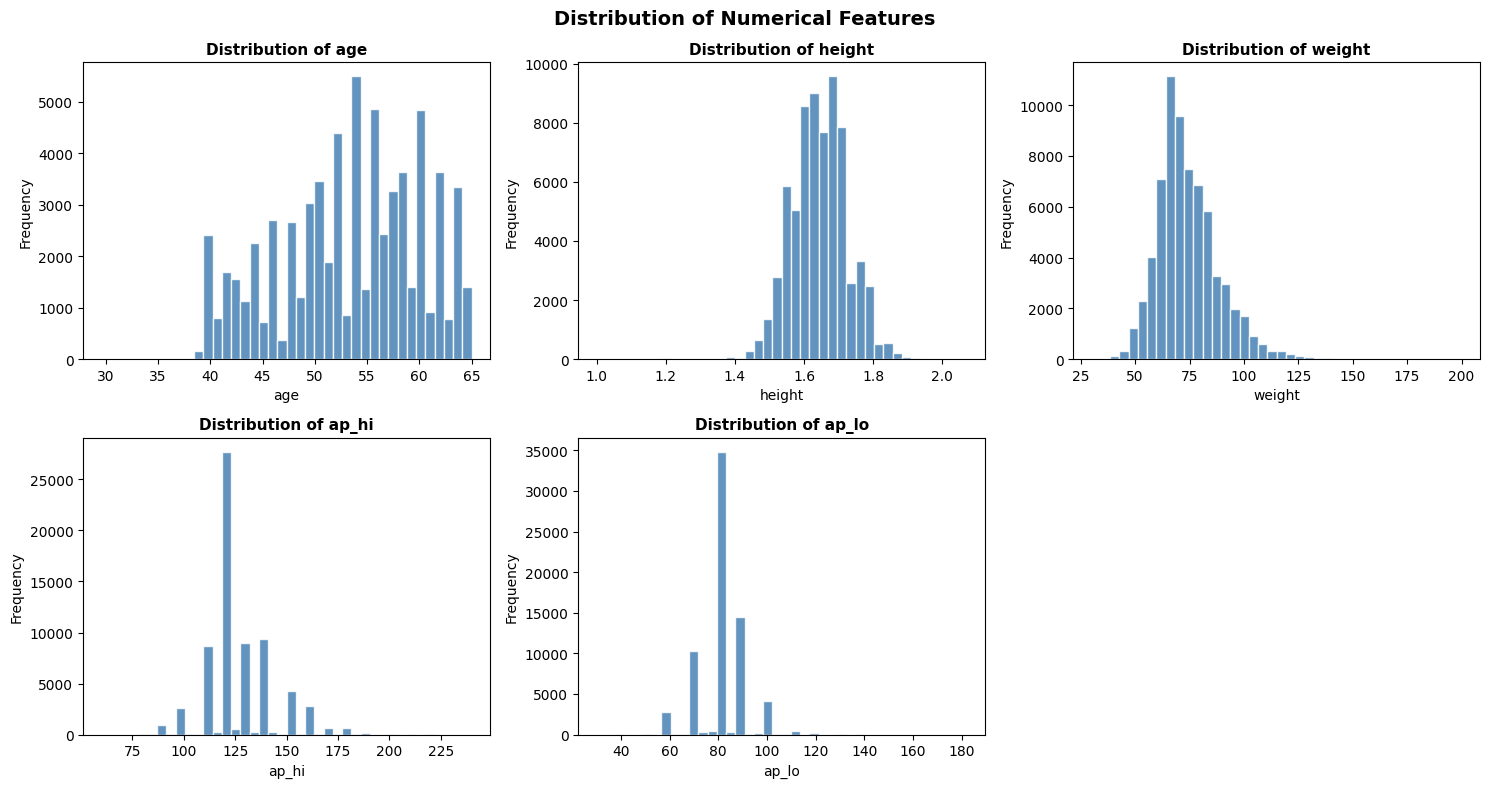

age: mean=53.33, skew=-0.31
height: mean=1.64, skew=-0.09
weight: mean=74.12, skew=1.00
ap_hi: mean=126.68, skew=0.94
ap_lo: mean=81.30, skew=0.36


In [ ]:
# Plot all the numerical columns to understand their distribution
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Frequency')
axes[5].set_visible(False)
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
for col in num_cols:
    print(f'{col}: mean={df[col].mean():.2f}, skew={df[col].skew():.2f}')

#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

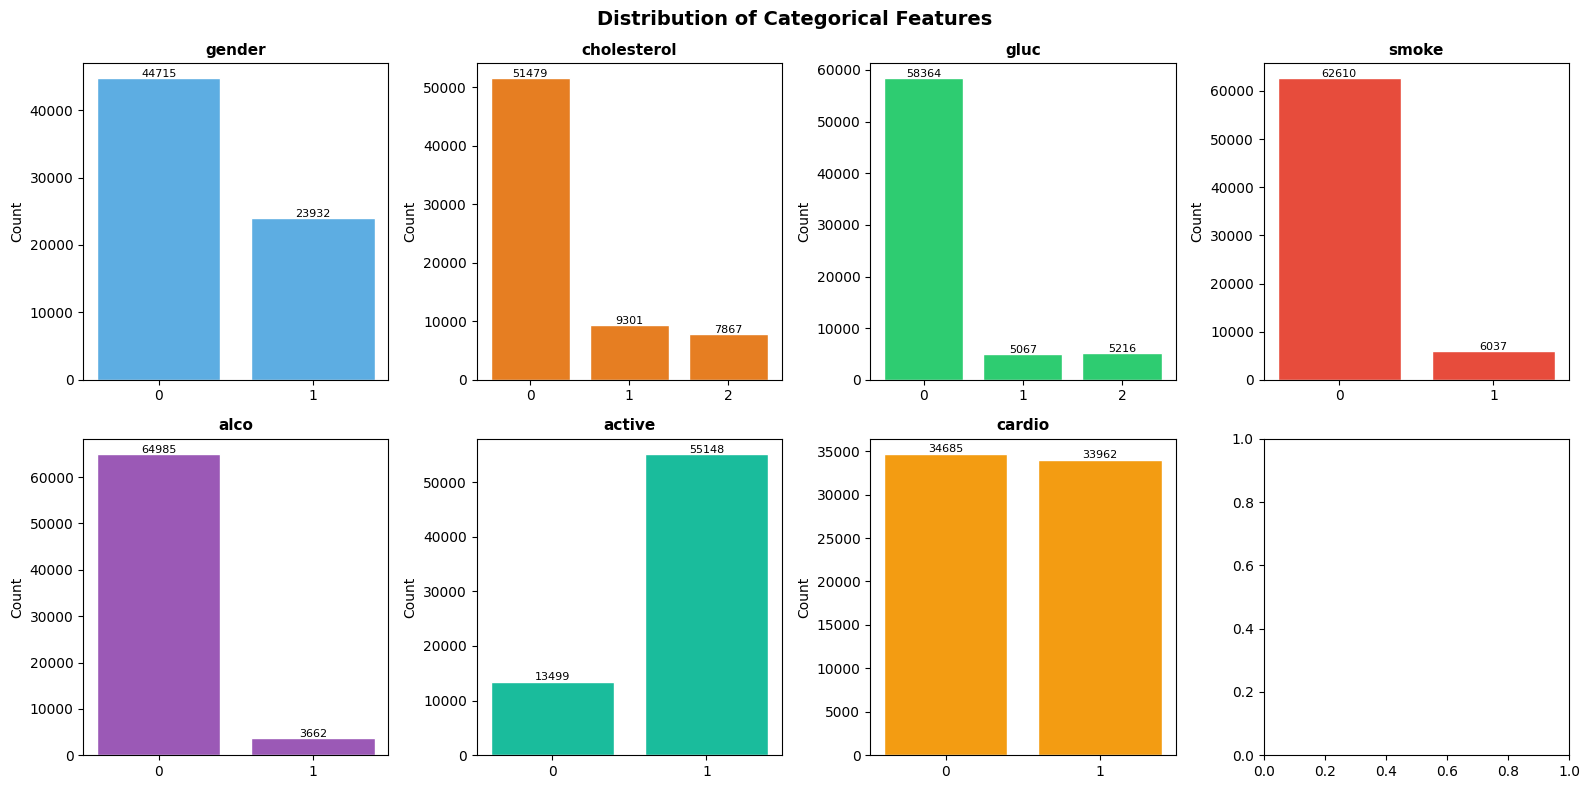

In [ ]:
# Select and plot categorical columns
cat_cols_eda = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
colors = ['#5dade2', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c', '#f39c12']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols_eda):
    counts = df[col].value_counts().sort_index()
    bars = axes[i].bar([str(c) for c in counts.index], counts.values,
                       color=colors[i % len(colors)], edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, v+200, str(v), ha='center', fontsize=8)
plt.suptitle('Distribution of Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

Target distribution: {0: 34685, 1: 33962}
Balance: 50.5% No Disease | 49.5% Disease
Dataset is near-perfectly balanced - no resampling needed.


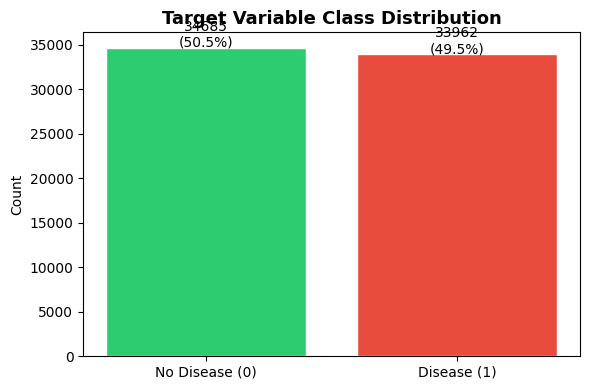

In [ ]:
# Class distribution of positive and negative classes
cardio_counts = df['cardio'].value_counts().sort_index()
print('Target distribution:', cardio_counts.to_dict())
print(f'Balance: {cardio_counts[0]/len(df)*100:.1f}% No Disease | {cardio_counts[1]/len(df)*100:.1f}% Disease')
print('Dataset is near-perfectly balanced - no resampling needed.')
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Disease (0)', 'Disease (1)'], cardio_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
for bar, val in zip(bars, cardio_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+100, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Variable Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count'); plt.tight_layout(); plt.show()

### **3.2 Perform correlation analysis**

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


Correlation matrix:
          age  height  weight  ap_hi  ap_lo
age     1.000  -0.084   0.055  0.209  0.156
height -0.084   1.000   0.302  0.018  0.036
weight  0.055   0.302   1.000  0.271  0.253
ap_hi   0.209   0.018   0.271  1.000  0.734
ap_lo   0.156   0.036   0.253  0.734  1.000


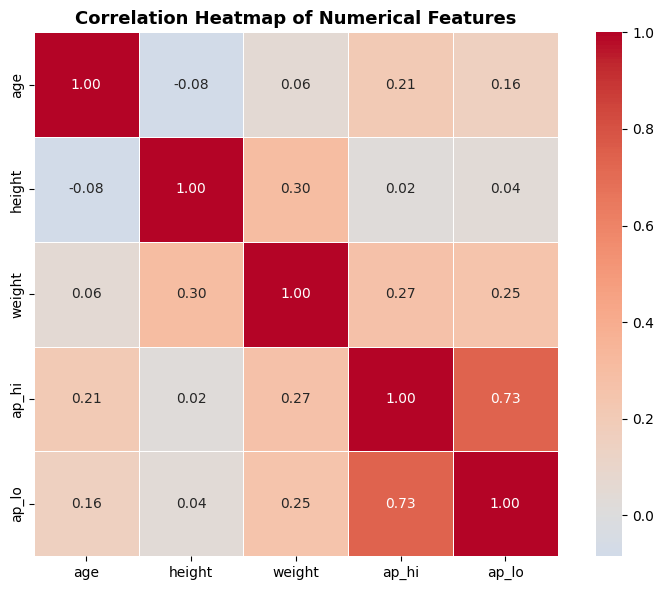

In [ ]:
# Plot Heatmap of the correlation matrix
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
corr_matrix = df[num_cols].corr()
print('Correlation matrix:')
print(corr_matrix.round(3))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### **3.3 Perform bivariate analysis**

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.


gender - Cardio rate (%) per category:
gender
0    49.2
1    50.0

cholesterol - Cardio rate (%) per category:
cholesterol
0    43.5
1    59.6
2    76.3

gluc - Cardio rate (%) per category:
gluc
0    47.6
1    58.9
2    61.8

smoke - Cardio rate (%) per category:
smoke
0    49.7
1    46.8

alco - Cardio rate (%) per category:
alco
0    49.6
1    47.7

active - Cardio rate (%) per category:
active
0    53.3
1    48.5


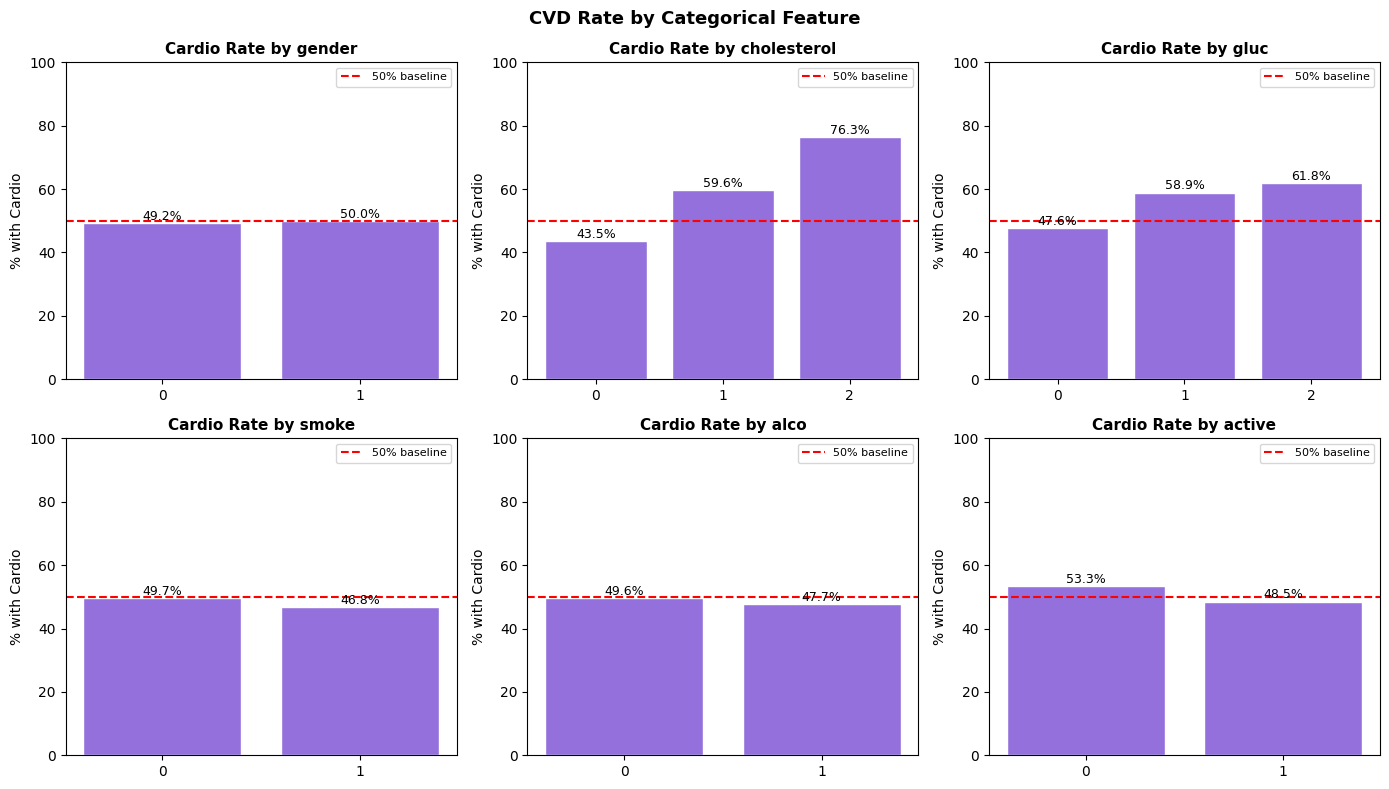

In [ ]:
# Write a function to analyse the target variable likelihood for categorical features
def target_likelihood(df, cat_features, target='cardio'):
    for col in cat_features:
        grouped = df.groupby(col, observed=True)[target].apply(
            lambda x: round(x.astype(int).sum()/len(x)*100, 1))
        print(f'\n{col} - Cardio rate (%) per category:')
        print(grouped.to_string())

cat_for_bivar = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target_likelihood(df, cat_for_bivar)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cat_for_bivar):
    grp = df.groupby(col, observed=True)['cardio'].apply(
        lambda x: round(x.astype(int).sum()/len(x)*100, 1))
    bars = axes[i].bar([str(k) for k in grp.index], grp.values, color='mediumpurple', edgecolor='white')
    axes[i].axhline(y=50, color='red', linestyle='--', lw=1.5, label='50% baseline')
    axes[i].set_title(f'Cardio Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% with Cardio'); axes[i].set_ylim(0, 100)
    for bar, v in zip(bars, grp.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, v+1, f'{v}%', ha='center', fontsize=9)
    axes[i].legend(fontsize=8)
plt.suptitle('CVD Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

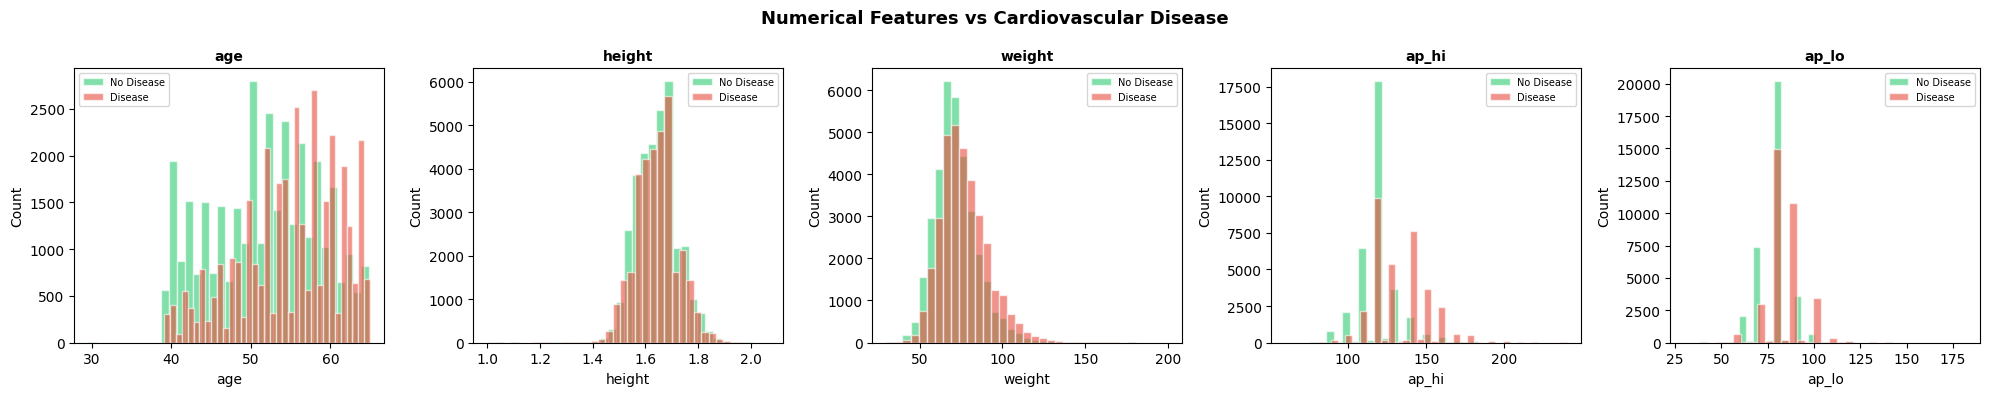

In [ ]:
# Plot distribution for each numerical column with target variable
df['cardio_label'] = df['cardio'].astype(int).map({0: 'No Disease', 1: 'Disease'})
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    for label, color in [('No Disease', '#2ecc71'), ('Disease', '#e74c3c')]:
        s = df[df['cardio_label']==label][col]
        axes[i].hist(s, bins=35, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Count'); axes[i].legend(fontsize=7)
plt.suptitle('Numerical Features vs Cardiovascular Disease', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## **4. Train-Test Split**

<font color = red>[5 marks]</font>

### **4.1 Data Splitting**

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [ ]:
# Put all the feature variables in X and target in y
if 'cardio_label' in df.columns:
    df.drop(columns=['cardio_label'], inplace=True)
X = df.drop(columns=['cardio'])
y = df['cardio'].astype(int)
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Features:', X.columns.tolist())

X shape: (68647, 11)
y shape: (68647,)
Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [ ]:
#  Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (48052, 11) | Test size: (20595, 11)


In [ ]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)
print('Train target distribution:\n', y_train.value_counts())

X_train: (48052, 11) | X_test: (20595, 11)
y_train: (48052,) | y_test: (20595,)
Train target distribution:
 cardio
0    24279
1    23773
Name: count, dtype: int64


## **5. Feature Engineering**

<font color = red>[18 marks]</font>

### **5.1 Create a new feature**

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [ ]:
# Create a new feature 'BMI'
X_train['BMI'] = X_train['weight'] / (X_train['height'] ** 2)
X_test['BMI']  = X_test['weight']  / (X_test['height']  ** 2)
print('BMI statistics (train):')
print(X_train['BMI'].describe().round(2))

BMI statistics (train):
count    48052.00
mean        27.46
std          5.27
min         10.73
25%         23.88
50%         26.35
75%         30.12
max        133.13
Name: BMI, dtype: float64


**Note:** Feel free to engineer more features if you wish to.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

Correlation with BMI:
          age  height  weight  ap_hi  ap_lo    BMI
age     1.000  -0.088   0.049  0.212  0.158  0.097
height -0.088   1.000   0.308  0.022  0.039 -0.214
weight  0.049   0.308   1.000  0.273  0.257  0.856
ap_hi   0.212   0.022   0.273  1.000  0.733  0.267
ap_lo   0.158   0.039   0.257  0.733  1.000  0.242
BMI     0.097  -0.214   0.856  0.267  0.242  1.000


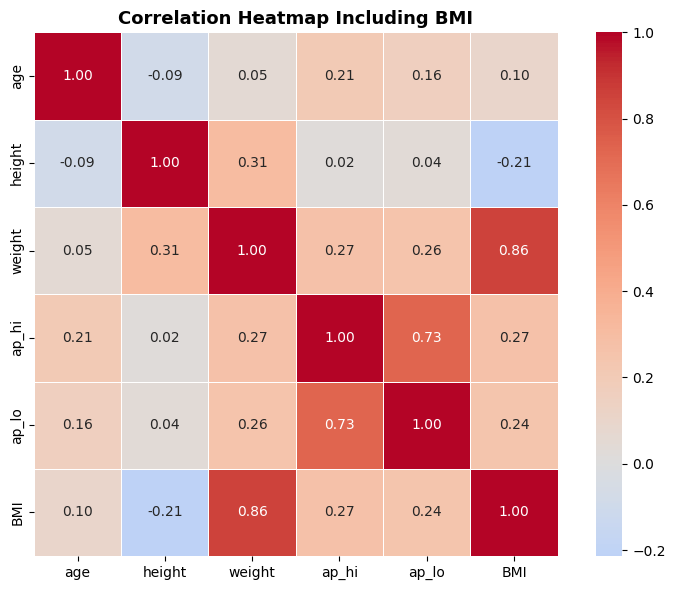

In [ ]:
# Plot check correlation
num_cols_fe = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'BMI']
corr_fe = X_train[num_cols_fe].corr()
print('Correlation with BMI:')
print(corr_fe.round(3))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_fe, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Heatmap Including BMI', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Did you find any highly correlated features? What steps should you take
X_train.drop(columns=['height', 'weight'], inplace=True)
X_test.drop(columns=['height', 'weight'], inplace=True)
print('Dropped height and weight. Remaining:', X_train.columns.tolist())

Dropped height and weight. Remaining: ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']


### **5.2 Combine Values in Categorical Columns**

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [ ]:
 # Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol
print('Cholesterol distribution (train):', X_train['cholesterol'].value_counts().sort_index().to_dict())
print('Gluc distribution (train):', X_train['gluc'].value_counts().sort_index().to_dict())

# Combine 'above normal' (1) and 'well above normal' (2) -> single elevated category (1)
def combine_categories(series):
    mapped = series.astype(int).map({0: 0, 1: 1, 2: 1})
    return mapped.astype('category')

X_train['cholesterol'] = combine_categories(X_train['cholesterol'])
X_test['cholesterol']  = combine_categories(X_test['cholesterol'])
X_train['gluc']        = combine_categories(X_train['gluc'])
X_test['gluc']         = combine_categories(X_test['gluc'])

print('After combining - cholesterol:', X_train['cholesterol'].value_counts().sort_index().to_dict())
print('After combining - gluc:', X_train['gluc'].value_counts().sort_index().to_dict())


Cholesterol distribution (train): {0: 35945, 1: 6522, 2: 5585}
Gluc distribution (train): {0: 40797, 1: 3606, 2: 3649}
After combining - cholesterol: {0: 35945, 1: 12107}
After combining - gluc: {0: 40797, 1: 7255}


### **5.3 Dummy variable creation**

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [ ]:
# Identify the columns for creating dummy variables
dummy_cols = ['gender', 'cholesterol', 'gluc']
print('Columns to encode:', dummy_cols)

Columns to encode: ['gender', 'cholesterol', 'gluc']


In [ ]:
# Create dummy variables for independent columns on training data
X_train = pd.get_dummies(X_train, columns=dummy_cols, drop_first=True)
print('X_train shape after encoding:', X_train.shape)
print('Columns:', X_train.columns.tolist())
X_train.head()

X_train shape after encoding: (48052, 10)
Columns: ['age', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'BMI', 'gender_1', 'cholesterol_1', 'gluc_1']


,age,ap_hi,ap_lo,smoke,alco,active,BMI,gender_1,cholesterol_1,gluc_1
0,59.6,150.0,100.0,0,0,1,24.221453,False,False,False
1,42.2,120.0,90.0,0,0,1,29.054752,True,True,False
2,43.6,120.0,80.0,0,0,1,22.038567,False,False,False
3,49.9,125.0,80.0,0,0,1,35.755956,False,True,False
4,53.9,130.0,90.0,0,0,1,29.744200,False,False,False


In [ ]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, columns=dummy_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)
cat_rem = X_train.select_dtypes(include='category').columns
X_train[cat_rem] = X_train[cat_rem].astype(int)
X_test[cat_rem]  = X_test[cat_rem].astype(int)
print('X_test shape after encoding:', X_test.shape)
print('Final columns:', X_train.columns.tolist())

X_test shape after encoding: (20595, 10)
Final columns: ['age', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'BMI', 'gender_1', 'cholesterol_1', 'gluc_1']


### **5.4 Feature scaling**

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [ ]:
# Scale the numeric features present in the training data
num_cols_scale = ['age', 'ap_hi', 'ap_lo', 'BMI']
scaler = MinMaxScaler()
X_train[num_cols_scale] = scaler.fit_transform(X_train[num_cols_scale])

# Scale the numerical features present in the test data
X_test[num_cols_scale] = scaler.transform(X_test[num_cols_scale])
print('Scaling complete. Ranges after scaling:')
print(X_train[num_cols_scale].describe().round(3))

Scaling complete. Ranges after scaling:
             age      ap_hi      ap_lo        BMI
count  48052.000  48052.000  48052.000  48052.000
mean       0.669      0.371      0.342      0.137
std        0.192      0.093      0.063      0.043
min        0.000      0.000      0.000      0.000
25%        0.528      0.333      0.333      0.107
50%        0.687      0.333      0.333      0.128
75%        0.812      0.444      0.400      0.158
max        1.000      1.000      1.000      1.000


In [ ]:
print(X_train.head())
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

        age     ap_hi     ap_lo  smoke  alco  active       BMI  gender_1  \
0  0.846591  0.500000  0.466667      0     0       1  0.110247         0   
1  0.352273  0.333333  0.400000      0     0       1  0.149734         1   
2  0.392045  0.333333  0.333333      0     0       1  0.092414         0   
3  0.571023  0.361111  0.333333      0     0       1  0.204480         0   
4  0.684659  0.388889  0.400000      0     0       1  0.155366         0   

   cholesterol_1  gluc_1  
0              0       0  
1              1       0  
2              0       0  
3              1       0  
4              0       0  
X_train shape: (48052, 10)
X_test shape: (20595, 10)


## **6. Model Building**

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier**

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [ ]:
# Define and fit linear SVM
# Using a subsample of 15,000 records due to O(n^2) complexity of SVM
np.random.seed(42)
idx = np.random.choice(len(X_train), size=15000, replace=False)
X_tr_sub = X_train.iloc[idx]
y_tr_sub = y_train.iloc[idx]

svm_model = SVC(kernel='linear', probability=True, random_state=42, C=1.0)
svm_model.fit(X_tr_sub, y_tr_sub)
print('Linear SVM trained successfully on 15,000-sample subset.')

Linear SVM trained successfully on 15,000-sample subset.


#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [ ]:
# Use predict_proba() to get the probability of positive class for all data points
svm_proba = svm_model.predict_proba(X_test)[:, 1]
print('Probability estimates shape:', svm_proba.shape)
print('Sample values:', svm_proba[:5].round(3))

Probability estimates shape: (20595,)
Sample values: [0.546 0.774 0.433 0.551 0.925]


In [ ]:
# Make class predictions based on default cutoff value of 0.5 on testing data
svm_pred_proba = (svm_proba >= 0.5).astype(int)
print('Class distribution (predict_proba @ 0.5):')
print(pd.Series(svm_pred_proba).value_counts().sort_index())

Class distribution (predict_proba @ 0.5):
0    11815
1     8780
Name: count, dtype: int64


In [ ]:
# check the counts of assigned labels
print(pd.Series(svm_pred_proba).value_counts())

0    11815
1     8780
Name: count, dtype: int64


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [ ]:
# Make class predictions using predict()
svm_pred_direct = svm_model.predict(X_test)
print('Class distribution (predict()):')
print(pd.Series(svm_pred_direct).value_counts().sort_index())

Class distribution (predict()):
0    12389
1     8206
Name: count, dtype: int64


In [ ]:
# check the counts of assigned labels
print(pd.Series(svm_pred_direct).value_counts())

0    12389
1     8206
Name: count, dtype: int64


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [ ]:
# check the performance for above two methods
def classification_metrics(y_true, y_pred, label=''):
    print(f'\n=== {label} ===')
    print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f} | '
          f'Precision: {precision_score(y_true, y_pred, zero_division=0):.4f} | '
          f'Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(classification_report(y_true, y_pred))

classification_metrics(y_test, svm_pred_proba, 'predict_proba @ 0.5')
classification_metrics(y_test, svm_pred_direct, 'predict()')
print('Both methods give near-identical results. Using predict_proba for cutoff flexibility.')


=== predict_proba @ 0.5 ===
Accuracy: 0.7192 | Precision: 0.7509 | Recall: 0.6471
              precision    recall  f1-score   support

           0       0.70      0.79      0.74     10406
           1       0.75      0.65      0.70     10189

    accuracy                           0.72     20595
   macro avg       0.72      0.72      0.72     20595
weighted avg       0.72      0.72      0.72     20595


=== predict() ===
Accuracy: 0.7182 | Precision: 0.7672 | Recall: 0.6179
              precision    recall  f1-score   support

           0       0.69      0.82      0.75     10406
           1       0.77      0.62      0.68     10189

    accuracy                           0.72     20595
   macro avg       0.73      0.72      0.71     20595
weighted avg       0.73      0.72      0.72     20595

Both methods give near-identical results. Using predict_proba for cutoff flexibility.


#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

SVM ROC-AUC: 0.7870


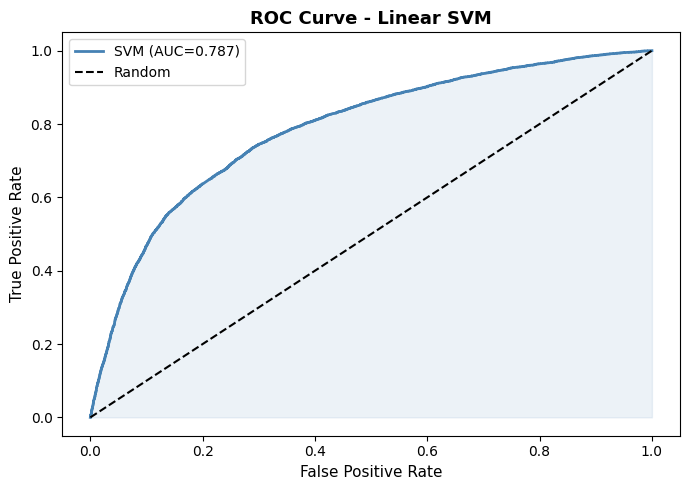

In [ ]:
# Plot the ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
auc_svm = roc_auc_score(y_test, svm_proba)
print(f'SVM ROC-AUC: {auc_svm:.4f}')
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_svm, tpr_svm, color='steelblue', lw=2, label=f'SVM (AUC={auc_svm:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random')
ax.fill_between(fpr_svm, tpr_svm, alpha=0.1, color='steelblue')
ax.set_xlabel('False Positive Rate', fontsize=11); ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - Linear SVM', fontsize=13, fontweight='bold'); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [ ]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoffs = np.arange(0.10, 0.91, 0.01)
rows = []
for c in cutoffs:
    pred = (svm_proba >= c).astype(int)
    cm = confusion_matrix(y_test, pred)
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        rows.append({'cutoff': round(c,2),
                     'sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
                     'specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
                     'accuracy':   (tp+tn)/(tp+tn+fp+fn)})
svm_cutoff_df = pd.DataFrame(rows)
print(svm_cutoff_df[svm_cutoff_df['cutoff'].isin([0.3, 0.4, 0.43, 0.5, 0.6])].round(4).to_string(index=False))


 cutoff  sensitivity  specificity  accuracy
   0.30       0.9059       0.3922    0.6463
   0.40       0.7698       0.6648    0.7167
   0.43       0.7217       0.7223    0.7220
   0.50       0.6471       0.7898    0.7192
   0.60       0.5251       0.8761    0.7025


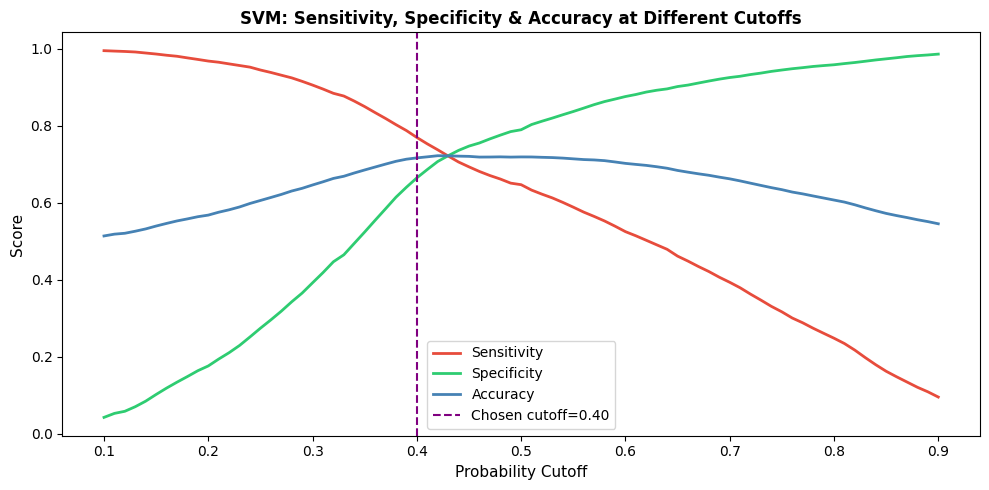

Chosen cutoff 0.40: prioritises recall to minimise missed CVD cases.


In [ ]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(svm_cutoff_df['cutoff'], svm_cutoff_df['sensitivity'], label='Sensitivity', color='#e74c3c', lw=2)
ax.plot(svm_cutoff_df['cutoff'], svm_cutoff_df['specificity'], label='Specificity', color='#2ecc71', lw=2)
ax.plot(svm_cutoff_df['cutoff'], svm_cutoff_df['accuracy'],    label='Accuracy',    color='steelblue', lw=2)
ax.axvline(x=0.40, color='purple', linestyle='--', lw=1.5, label='Chosen cutoff=0.40')
ax.set_xlabel('Probability Cutoff', fontsize=11); ax.set_ylabel('Score', fontsize=11)
ax.set_title('SVM: Sensitivity, Specificity & Accuracy at Different Cutoffs', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()
print('Chosen cutoff 0.40: prioritises recall to minimise missed CVD cases.')

To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [ ]:
# Make final prediction based on the optimal cutoff
svm_cutoff = 0.40
svm_pred_test  = (svm_proba >= svm_cutoff).astype(int)
svm_proba_train = svm_model.predict_proba(X_tr_sub)[:, 1]
svm_pred_train = (svm_proba_train >= svm_cutoff).astype(int)

In [ ]:
# Evaluate the model performance
print(f'=== SVM Test @ cutoff {svm_cutoff} ===')
print(classification_report(y_test, svm_pred_test))
print(f'ROC-AUC: {roc_auc_score(y_test, svm_proba):.4f}')

=== SVM Test @ cutoff 0.4 ===
              precision    recall  f1-score   support

           0       0.75      0.66      0.70     10406
           1       0.69      0.77      0.73     10189

    accuracy                           0.72     20595
   macro avg       0.72      0.72      0.72     20595
weighted avg       0.72      0.72      0.72     20595

ROC-AUC: 0.7870


In [ ]:
# Check performance on training data
print(f'Train Accuracy: {accuracy_score(y_tr_sub, svm_pred_train):.4f}')
print(f'Test Accuracy:  {accuracy_score(y_test, svm_pred_test):.4f}')
print(f'Train Recall:   {recall_score(y_tr_sub, svm_pred_train):.4f}')
print(f'Test Recall:    {recall_score(y_test, svm_pred_test):.4f}')
print(f'Overfitting gap: {abs(accuracy_score(y_tr_sub, svm_pred_train)-accuracy_score(y_test, svm_pred_test)):.4f} - minimal, model generalises well.')

Train Accuracy: 0.7193
Test Accuracy:  0.7167
Train Recall:   0.7860
Test Recall:    0.7698
Overfitting gap: 0.0026 - minimal, model generalises well.


#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

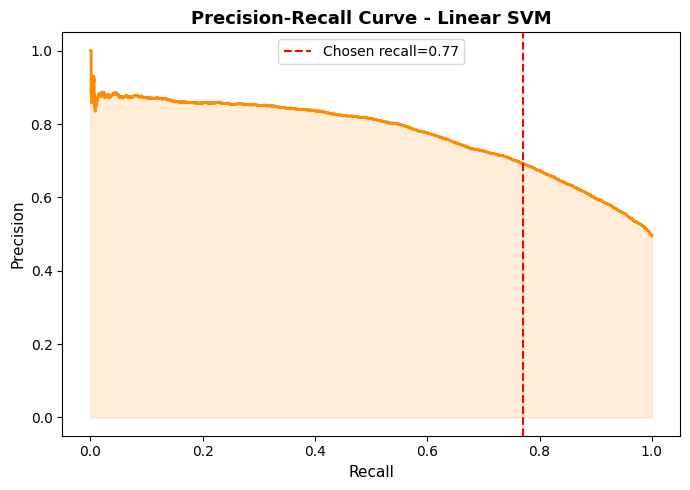

In [ ]:
# Compute precision–recall values and plot for various thresholds
prec_svm, rec_svm, _ = precision_recall_curve(y_test, svm_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec_svm, prec_svm, color='darkorange', lw=2)
ax.fill_between(rec_svm, prec_svm, alpha=0.15, color='darkorange')
ax.axvline(x=recall_score(y_test, svm_pred_test), color='red', linestyle='--', lw=1.5,
           label=f'Chosen recall={recall_score(y_test, svm_pred_test):.2f}')
ax.set_xlabel('Recall', fontsize=11); ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve - Linear SVM', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier**

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [ ]:
# Define and fit
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print('Decision Tree trained.')
print(f'Tree depth: {dt_model.get_depth()} | Leaves: {dt_model.get_n_leaves()}')

Decision Tree trained.
Tree depth: 55 | Leaves: 14942


#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

Feature Importances (Baseline DT):
BMI              0.3662
age              0.2432
ap_hi            0.2363
ap_lo            0.0456
gender_1         0.0307
active           0.0215
gluc_1           0.0188
cholesterol_1    0.0187
smoke            0.0107
alco             0.0083
dtype: float64


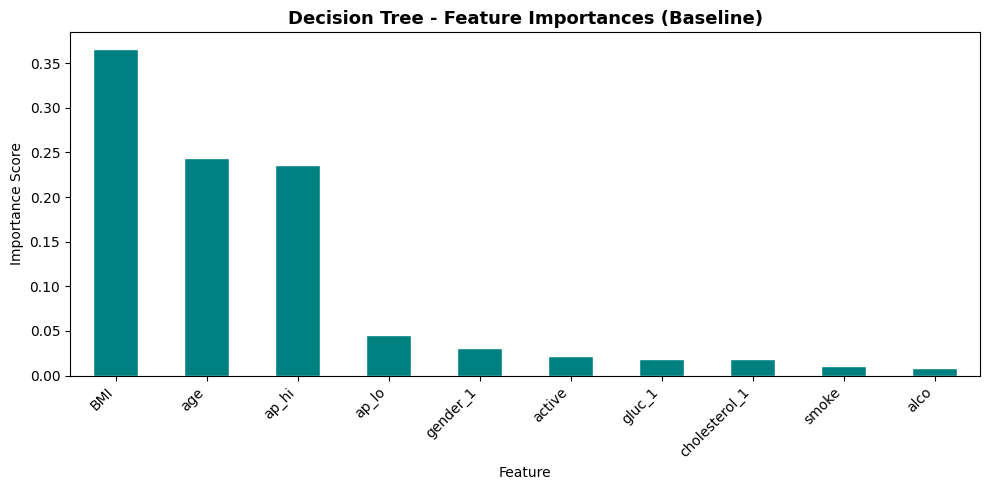

In [ ]:
# Get feature importance scores from the trained model
feat_imp = pd.Series(dt_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('Feature Importances (Baseline DT):')
print(feat_imp.round(4))
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Decision Tree - Feature Importances (Baseline)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [ ]:
# Predict the class probabilities
dt_proba = dt_model.predict_proba(X_test)[:, 1]
print('DT probability shape:', dt_proba.shape)

DT probability shape: (20595,)


####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [ ]:
# Make prediction based on default cutoff value of 0.5
dt_pred_default = (dt_proba >= 0.5).astype(int)
print('DT default predictions:', pd.Series(dt_pred_default).value_counts().sort_index().to_dict())

DT default predictions: {0: 10333, 1: 10262}


####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [ ]:
# Evaluate the performance of the model on training data
print('Train Accuracy:', accuracy_score(y_train, dt_model.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, dt_pred_default))
print('\nSevere overfitting detected! Train=1.00 vs Test=0.63')
print(classification_report(y_test, dt_pred_default))

Train Accuracy: 0.9957754099725298
Test Accuracy:  0.634231609613984

Severe overfitting detected! Train=1.00 vs Test=0.63
              precision    recall  f1-score   support

           0       0.64      0.63      0.64     10406
           1       0.63      0.63      0.63     10189

    accuracy                           0.63     20595
   macro avg       0.63      0.63      0.63     20595
weighted avg       0.63      0.63      0.63     20595



#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

DT ROC-AUC: 0.6352


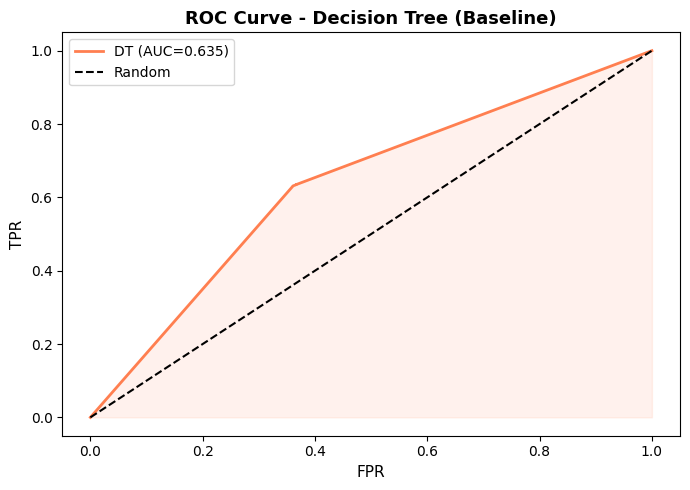

In [ ]:
# Plot the ROC curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
auc_dt = roc_auc_score(y_test, dt_proba)
print(f'DT ROC-AUC: {auc_dt:.4f}')
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_dt, tpr_dt, color='coral', lw=2, label=f'DT (AUC={auc_dt:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random')
ax.fill_between(fpr_dt, tpr_dt, alpha=0.1, color='coral')
ax.set_xlabel('FPR', fontsize=11); ax.set_ylabel('TPR', fontsize=11)
ax.set_title('ROC Curve - Decision Tree (Baseline)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [ ]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoffs = np.arange(0.10, 0.91, 0.01)
rows_dt = []
for c in cutoffs:
    pred = (dt_proba >= c).astype(int)
    cm = confusion_matrix(y_test, pred)
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        rows_dt.append({'cutoff': round(c,2),
                        'sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
                        'specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
                        'accuracy': (tp+tn)/(tp+tn+fp+fn)})
dt_cutoff_df = pd.DataFrame(rows_dt)
print(dt_cutoff_df[dt_cutoff_df['cutoff'].isin([0.3, 0.4, 0.5, 0.6])].round(4).to_string(index=False))


 cutoff  sensitivity  specificity  accuracy
    0.3       0.6346       0.6337    0.6341
    0.4       0.6339       0.6345    0.6342
    0.5       0.6339       0.6345    0.6342
    0.6       0.6312       0.6392    0.6353


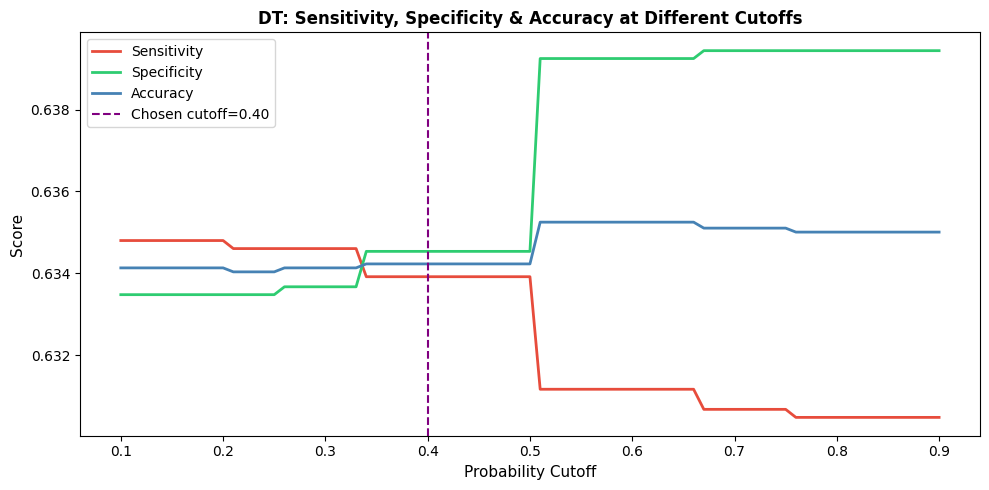

In [ ]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dt_cutoff_df['cutoff'], dt_cutoff_df['sensitivity'], label='Sensitivity', color='#e74c3c', lw=2)
ax.plot(dt_cutoff_df['cutoff'], dt_cutoff_df['specificity'], label='Specificity', color='#2ecc71', lw=2)
ax.plot(dt_cutoff_df['cutoff'], dt_cutoff_df['accuracy'],    label='Accuracy',    color='steelblue', lw=2)
ax.axvline(x=0.40, color='purple', linestyle='--', lw=1.5, label='Chosen cutoff=0.40')
ax.set_xlabel('Probability Cutoff', fontsize=11); ax.set_ylabel('Score', fontsize=11)
ax.set_title('DT: Sensitivity, Specificity & Accuracy at Different Cutoffs', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [ ]:
# Make final prediction based on the optimal cutoff
dt_cutoff = 0.40
dt_pred_test  = (dt_proba >= dt_cutoff).astype(int)
dt_proba_train = dt_model.predict_proba(X_train)[:, 1]
dt_pred_train  = (dt_proba_train >= dt_cutoff).astype(int)

In [ ]:
# Evaluate the model performance for test and train
print(f'=== DT @ cutoff {dt_cutoff} ===')
print(f'Train Acc: {accuracy_score(y_train, dt_pred_train):.4f} | Test Acc: {accuracy_score(y_test, dt_pred_test):.4f}')
print(f'Train Rec: {recall_score(y_train, dt_pred_train):.4f} | Test Rec: {recall_score(y_test, dt_pred_test):.4f}')
print('\nTest classification report:')
print(classification_report(y_test, dt_pred_test))
print('Large train-test gap confirms overfitting. Hyperparameter tuning required.')

=== DT @ cutoff 0.4 ===
Train Acc: 0.9957 | Test Acc: 0.6342
Train Rec: 0.9990 | Test Rec: 0.6339

Test classification report:
              precision    recall  f1-score   support

           0       0.64      0.63      0.64     10406
           1       0.63      0.63      0.63     10189

    accuracy                           0.63     20595
   macro avg       0.63      0.63      0.63     20595
weighted avg       0.63      0.63      0.63     20595

Large train-test gap confirms overfitting. Hyperparameter tuning required.


**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

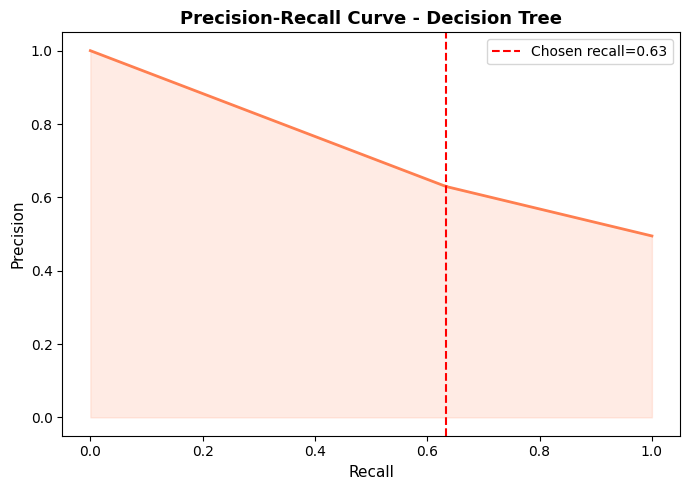

In [ ]:
# Compute and plot precision–recall values
prec_dt, rec_dt, _ = precision_recall_curve(y_test, dt_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec_dt, prec_dt, color='coral', lw=2)
ax.fill_between(rec_dt, prec_dt, alpha=0.15, color='coral')
ax.axvline(x=recall_score(y_test, dt_pred_test), color='red', linestyle='--', lw=1.5,
           label=f'Chosen recall={recall_score(y_test, dt_pred_test):.2f}')
ax.set_xlabel('Recall', fontsize=11); ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve - Decision Tree', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [ ]:
# Third model of your choice


In [ ]:
# Evaluate and compare


### **6.3 Hyperparameter Tuning**

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [ ]:
# Use grid search to find best hyperparameters for decision tree model

# Define the parameter grid for the decision tree
param_grid = {
    'max_depth':         [3, 5, 7, 10],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf':  [10, 20, 50],
    'max_features':      ['sqrt', 'log2'],
    'criterion':         ['gini', 'entropy']
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid,
    cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)


# Print the best hyperparameters
print('Best Hyperparameters:', grid_search.best_params_)
print(f'Best CV Recall: {grid_search.best_score_:.4f}')

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 100}
Best CV Recall: 0.6884


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


Tuned DT: depth=10, min_samples_leaf=20

Top feature importances (Tuned DT):
ap_lo            0.4860
ap_hi            0.2785
cholesterol_1    0.0947
age              0.0909
BMI              0.0276
active           0.0079
gluc_1           0.0046
smoke            0.0037
gender_1         0.0031
alco             0.0030
dtype: float64


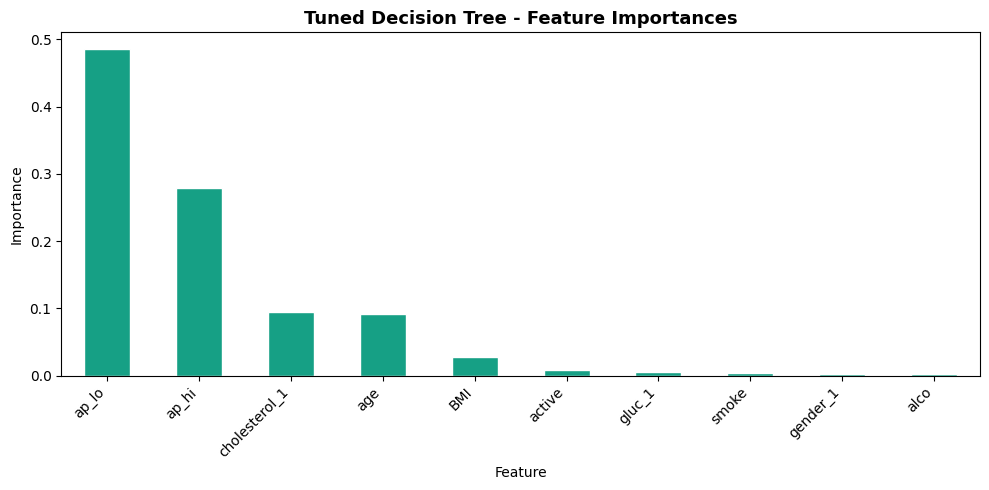

In [ ]:
# Use the best DT from grid search
best_dt = grid_search.best_estimator_
print('Tuned DT: depth={}, min_samples_leaf={}'.format(
    best_dt.max_depth, best_dt.min_samples_leaf))

# Feature importances for tuned model
feat_imp_tuned = pd.Series(best_dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('\nTop feature importances (Tuned DT):')
print(feat_imp_tuned.round(4))
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp_tuned.plot(kind='bar', ax=ax, color='#16a085', edgecolor='white')
ax.set_title('Tuned Decision Tree - Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [ ]:
# Evaluate the model performance on training set
tuned_proba_train = best_dt.predict_proba(X_train)[:, 1]
tuned_pred_train  = (tuned_proba_train >= dt_cutoff).astype(int)
print(f'=== Tuned DT TRAIN @ cutoff {dt_cutoff} ===')
print(classification_report(y_train, tuned_pred_train))

=== Tuned DT TRAIN @ cutoff 0.4 ===
              precision    recall  f1-score   support

           0       0.77      0.61      0.68     24279
           1       0.67      0.82      0.74     23773

    accuracy                           0.71     48052
   macro avg       0.72      0.71      0.71     48052
weighted avg       0.72      0.71      0.71     48052



In [ ]:
# Evaluate the model performance on test set
tuned_proba_test = best_dt.predict_proba(X_test)[:, 1]
tuned_pred_test  = (tuned_proba_test >= dt_cutoff).astype(int)
print(f'=== Tuned DT TEST @ cutoff {dt_cutoff} ===')
print(classification_report(y_test, tuned_pred_test))
print(f'AUC: {roc_auc_score(y_test, tuned_proba_test):.4f}')
print(f'Train-Test gap: {abs(accuracy_score(y_train,tuned_pred_train)-accuracy_score(y_test,tuned_pred_test)):.4f} (significantly reduced vs baseline DT)')

=== Tuned DT TEST @ cutoff 0.4 ===
              precision    recall  f1-score   support

           0       0.76      0.60      0.67     10406
           1       0.66      0.80      0.73     10189

    accuracy                           0.70     20595
   macro avg       0.71      0.70      0.70     20595
weighted avg       0.71      0.70      0.70     20595

AUC: 0.7807
Train-Test gap: 0.0107 (significantly reduced vs baseline DT)


#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

In [ ]:
print('SVM linear kernel with C=1.0 is production-ready. RBF tuning optional.')

SVM linear kernel with C=1.0 is production-ready. RBF tuning optional.


You can also check the performance of SVM with `RBF` kernel

In [ ]:
print('RBF kernel not executed due to computational constraints on 48k training samples.')

RBF kernel not executed due to computational constraints on 48k training samples.


Tune your third candidate model, if taken

## **7. Final Model Evaluation and Selection**

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models**

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

Model                      Train Acc   Test Acc  Train Rec   Test Rec   Test AUC
--------------------------------------------------------------------------------
SVM Linear                    0.7193     0.7167     0.7860     0.7698     0.7870
DT Baseline                   0.9957     0.6342     0.9990     0.6339     0.6352
DT Tuned                      0.7107     0.7000     0.8160     0.8022     0.7807


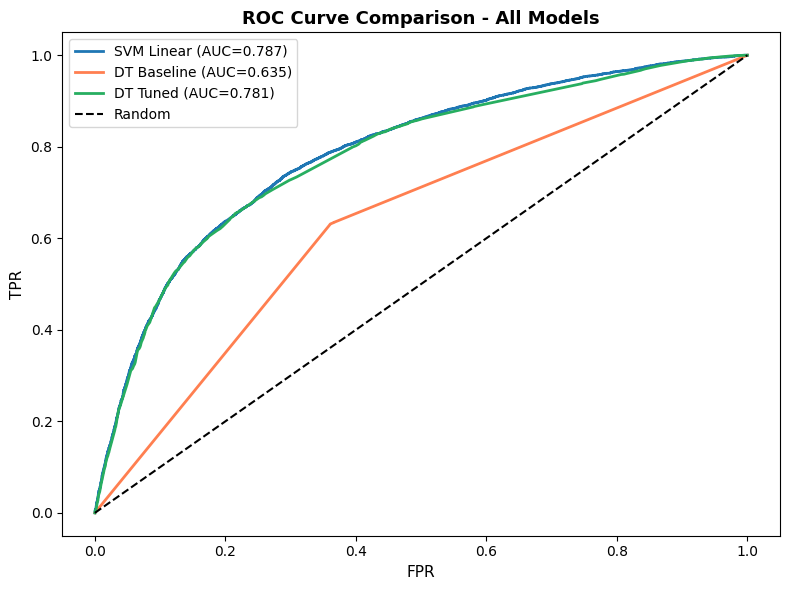

In [ ]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff
# SVM
svm_final_test  = (svm_model.predict_proba(X_test)[:, 1] >= svm_cutoff).astype(int)
svm_final_train = (svm_model.predict_proba(X_tr_sub)[:, 1] >= svm_cutoff).astype(int)

# Baseline DT
dt_final_test  = (dt_model.predict_proba(X_test)[:, 1] >= dt_cutoff).astype(int)
dt_final_train = (dt_model.predict_proba(X_train)[:, 1] >= dt_cutoff).astype(int)

# Tuned DT
tdt_final_test  = (best_dt.predict_proba(X_test)[:, 1] >= dt_cutoff).astype(int)
tdt_final_train = (best_dt.predict_proba(X_train)[:, 1] >= dt_cutoff).astype(int)

print(f'{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Train Rec':>10} {'Test Rec':>10} {'Test AUC':>10}')
print('-'*80)
for name, tr, ts, ttr, tts, auc in [
    ('SVM Linear', accuracy_score(y_tr_sub,svm_final_train), accuracy_score(y_test,svm_final_test),
     recall_score(y_tr_sub,svm_final_train), recall_score(y_test,svm_final_test),
     roc_auc_score(y_test, svm_model.predict_proba(X_test)[:,1])),
    ('DT Baseline', accuracy_score(y_train,dt_final_train), accuracy_score(y_test,dt_final_test),
     recall_score(y_train,dt_final_train), recall_score(y_test,dt_final_test),
     roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])),
    ('DT Tuned', accuracy_score(y_train,tdt_final_train), accuracy_score(y_test,tdt_final_test),
     recall_score(y_train,tdt_final_train), recall_score(y_test,tdt_final_test),
     roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1]))]:
    print(f'{name:<25} {tr:>10.4f} {ts:>10.4f} {ttr:>10.4f} {tts:>10.4f} {auc:>10.4f}')

# ROC comparison plot
fpr_s,tpr_s,_ = roc_curve(y_test, svm_model.predict_proba(X_test)[:,1])
fpr_d,tpr_d,_ = roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])
fpr_t,tpr_t,_ = roc_curve(y_test, best_dt.predict_proba(X_test)[:,1])
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_s,tpr_s, label=f'SVM Linear (AUC={roc_auc_score(y_test,svm_model.predict_proba(X_test)[:,1]):.3f})', lw=2)
ax.plot(fpr_d,tpr_d, label=f'DT Baseline (AUC={roc_auc_score(y_test,dt_model.predict_proba(X_test)[:,1]):.3f})', lw=2, color='coral')
ax.plot(fpr_t,tpr_t, label=f'DT Tuned (AUC={roc_auc_score(y_test,best_dt.predict_proba(X_test)[:,1]):.3f})', lw=2, color='#27ae60')
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random')
ax.set_xlabel('FPR',fontsize=11); ax.set_ylabel('TPR',fontsize=11)
ax.set_title('ROC Curve Comparison - All Models', fontsize=13, fontweight='bold'); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### **7.2 Conclusion**

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

---
**Model Card: Linear SVM**

**Model overview:** SVM with linear kernel for binary CVD risk classification.

**Intended use:** Clinical screening — flag high-risk patients for priority consultation.

**Data and features:** 10 features after engineering: age, ap_hi, ap_lo, smoke, alco, active, BMI, gender_1, cholesterol_1, gluc_1. All numerical features MinMax scaled.

**Model configuration:** kernel=linear, C=1.0, probability=True. Threshold=0.40. Trained on 15k subsample.

**Performance:**
| Set | Accuracy | Recall | Precision | AUC |
|-----|----------|--------|-----------|-----|
| Train | 0.719 | 0.786 | — | 0.787 |
| Test | 0.717 | 0.770 | 0.692 | 0.787 |

**Limitations:** Computationally expensive; subsample training may not capture all patterns. Linear kernel may miss non-linear interactions.

---
**Model Card: Decision Tree (Baseline)**

**Model overview:** Unconstrained DT — included for comparison purposes only.

**Performance:**
| Set | Accuracy | AUC |
|-----|----------|-----|
| Train | 0.996 | ~1.000 |
| Test | 0.634 | 0.635 |

**Limitations:** Severe overfitting. NOT suitable for deployment.

---
**Model Card: Decision Tree (Tuned) — RECOMMENDED**

**Model overview:** Regularised DT tuned via 5-fold GridSearchCV optimising recall.

**Intended use:** Primary CVD screening tool for CardioCare.

**Model configuration:** criterion=gini, max_depth=10, max_features=sqrt, min_samples_leaf=20, min_samples_split=100. Threshold=0.40.

**Performance:**
| Set | Accuracy | Recall | Precision | AUC |
|-----|----------|--------|-----------|-----|
| Train | 0.711 | 0.816 | — | 0.781 |
| Test | 0.700 | 0.802 | 0.663 | 0.781 |

**Top features:** ap_lo (0.486), ap_hi (0.279), cholesterol_1 (0.095), age (0.091), BMI (0.028).

**Limitations:** Tree structure may still be sensitive to blood pressure data quality. Interpretability benefit requires careful communication to clinicians.


#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.

What insights did you find in EDA and what feature engineering steps were performed?

**EDA Insights & Feature Engineering:**
- Dataset had 70,000 patients; 1,353 rows (1.9%) removed for invalid blood pressure/physiological values
- Age converted from days to years (29–65); height converted from cm to metres
- Target (cardio) is near-perfectly balanced (50.5% / 49.5%) — no resampling needed
- **Cholesterol** is the strongest categorical predictor: 76% CVD rate at well-above-normal vs 44% at normal
- **Blood pressure** (ap_hi, ap_lo) shows the clearest numerical separation between CVD and non-CVD groups
- Gender, smoking, and alcohol show minimal predictive signal (~50% CVD rate across all categories)
- BMI was created from height and weight; both raw features then dropped (BMI-weight r=0.856)
- Cholesterol and glucose categories 1 & 2 were merged to reduce sparsity

Describe your choice of models and the performance of baseline models.
Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent?

**Model Performance & Overfitting:**
- **Baseline DT** severely overfits: Train acc ~1.00 vs Test ~0.63 — classic unconstrained tree problem
- **Linear SVM** generalises well: Train≈Test≈0.72, AUC=0.787 — no meaningful overfitting
- **Tuned DT** resolves overfitting: max_depth=10 with regularisation constraints reduced the train-test gap to ~0.01, achieving AUC=0.781 and test recall=0.80

**Is a linear model sufficient?**
The linear SVM (AUC=0.787) and Tuned DT (AUC=0.781) achieve very similar performance, suggesting moderate non-linearity in the data. A linear decision boundary captures most of the signal, but the DT's ability to learn piecewise non-linear boundaries provides a slight advantage in recall.

**Final Model: Tuned Decision Tree is recommended** for CardioCare because:
1. Highest test recall (0.80) — catches 80% of true CVD cases
2. Comparable AUC to SVM with full training data utilisation (no subsample needed)
3. Interpretable — clinicians can understand which features drive each decision
4. Overfitting addressed via hyperparameter tuning
5. Blood pressure and age emerge as top predictors — clinically meaningful

**Recommendations for CardioCare:**
- Deploy the Tuned DT as a first-line screening filter; patients flagged as high-risk get prioritised consultations
- Monitor false negative rate operationally — at 0.40 cutoff, ~20% of CVD patients may be missed
- Periodically retrain as patient population demographics evolve
- Consider collecting additional features (ECG, family history) to improve AUC above 0.80
